In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
pip install timm

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [4]:
train_dir = "/kaggle/input/datasets/obulisainaren/retinal-oct-c8/RetinalOCT_Dataset/RetinalOCT_Dataset/train"
val_dir = "/kaggle/input/datasets/obulisainaren/retinal-oct-c8/RetinalOCT_Dataset/RetinalOCT_Dataset/val"

In [12]:
batch_size = 32
num_epochs = 15
learning_rate = 1e-4   # 🔥 FIXED (important)

In [13]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])   # 🔥 FIX
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

In [14]:
train_data = datasets.ImageFolder(train_dir, transform=train_transforms)
val_data = datasets.ImageFolder(val_dir, transform=val_transforms)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

num_classes = len(train_data.classes)
class_names = train_data.classes

print("Classes:", class_names)

Classes: ['AMD', 'CNV', 'CSR', 'DME', 'DR', 'DRUSEN', 'MH', 'NORMAL']


In [15]:
model = timm.create_model(
    'swin_tiny_patch4_window7_224',
    pretrained=False,
    num_classes=num_classes,
    drop_rate=0.2
)

model = model.to(device)

In [16]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

In [10]:
train_losses = []
val_losses = []
val_accuracies = []

In [17]:
best_acc = 0

for epoch in range(num_epochs):

    # TRAIN
    model.train()
    train_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    scheduler.step()

    # VALIDATION
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total

    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss/len(train_loader):.4f}")
    print(f"Val Loss: {val_loss/len(val_loader):.4f}")
    print(f"Accuracy: {acc:.4f}")

    # 🔥 SAVE BEST MODEL
    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), "best_model.pth")
        print("✅ Best model saved!")


Epoch 1
Train Loss: 1.3845
Val Loss: 0.9723
Accuracy: 0.5625
✅ Best model saved!

Epoch 2
Train Loss: 0.9426
Val Loss: 0.7680
Accuracy: 0.6775
✅ Best model saved!

Epoch 3
Train Loss: 0.7765
Val Loss: 0.6383
Accuracy: 0.7346
✅ Best model saved!

Epoch 4
Train Loss: 0.6774
Val Loss: 0.6319
Accuracy: 0.7407
✅ Best model saved!

Epoch 5
Train Loss: 0.5877
Val Loss: 0.5253
Accuracy: 0.7929
✅ Best model saved!

Epoch 6
Train Loss: 0.5238
Val Loss: 0.4772
Accuracy: 0.8229
✅ Best model saved!

Epoch 7
Train Loss: 0.4646
Val Loss: 0.4350
Accuracy: 0.8421
✅ Best model saved!

Epoch 8
Train Loss: 0.4142
Val Loss: 0.3859
Accuracy: 0.8586
✅ Best model saved!

Epoch 9
Train Loss: 0.3777
Val Loss: 0.3684
Accuracy: 0.8654
✅ Best model saved!

Epoch 10
Train Loss: 0.3566
Val Loss: 0.3578
Accuracy: 0.8668
✅ Best model saved!

Epoch 11
Train Loss: 0.3519
Val Loss: 0.3578
Accuracy: 0.8668

Epoch 12
Train Loss: 0.3491
Val Loss: 0.3538
Accuracy: 0.8704
✅ Best model saved!

Epoch 13
Train Loss: 0.3553
Val 

In [18]:
torch.save(model.state_dict(), "baseline_swin.pth")
print("Model saved!")

Model saved!


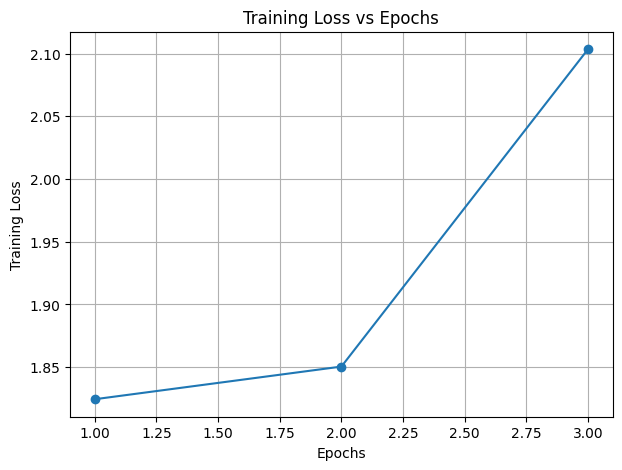

In [22]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(7, 5))
plt.plot(epochs, train_losses, marker='o')

plt.xlabel("Epochs")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epochs")

plt.grid()
plt.show()

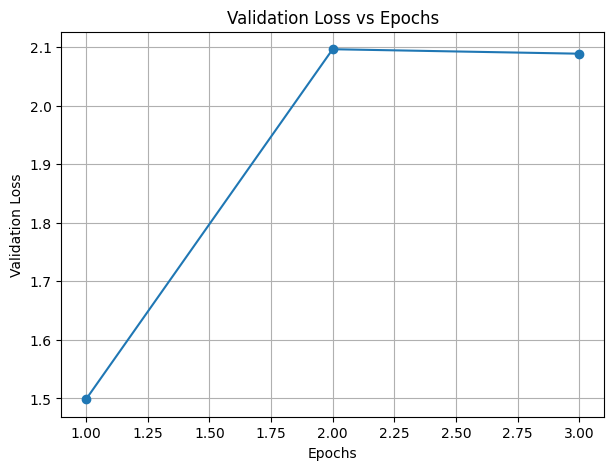

In [23]:
plt.figure(figsize=(7, 5))
plt.plot(epochs, val_losses, marker='o')

plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title("Validation Loss vs Epochs")

plt.grid()
plt.show()

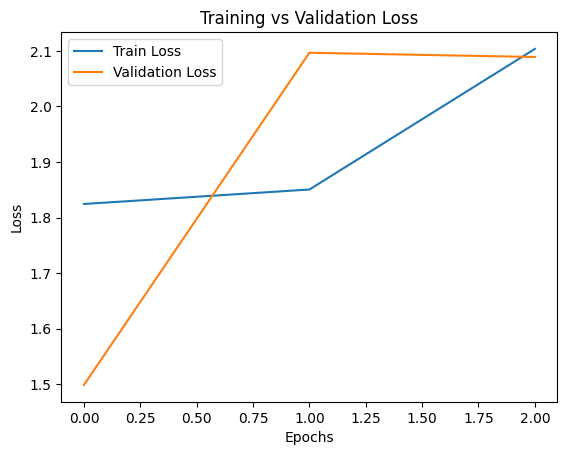

In [20]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

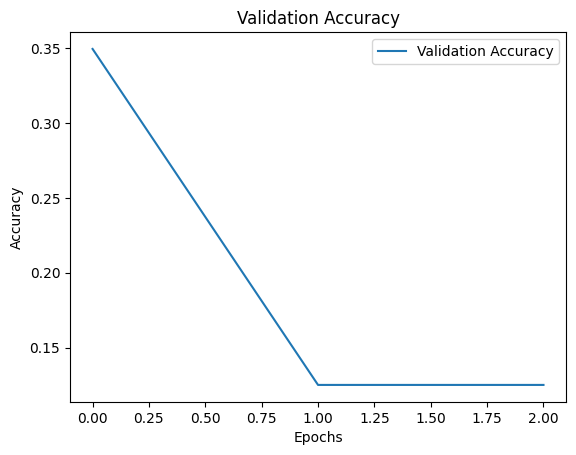

In [21]:
plt.figure()
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.legend()
plt.show()

In [24]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [25]:
y_true = []
y_pred = []
y_probs = []

model.eval()

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_probs.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probs = np.array(y_probs)

In [26]:
print("Classification Report:\n")

report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

Classification Report:

              precision    recall  f1-score   support

         AMD       0.99      1.00      1.00       350
         CNV       0.78      0.91      0.84       350
         CSR       0.99      0.95      0.97       350
         DME       0.82      0.75      0.78       350
          DR       0.87      0.98      0.92       350
      DRUSEN       0.77      0.59      0.67       350
          MH       0.98      0.89      0.93       350
      NORMAL       0.71      0.81      0.76       350

    accuracy                           0.86      2800
   macro avg       0.86      0.86      0.86      2800
weighted avg       0.86      0.86      0.86      2800



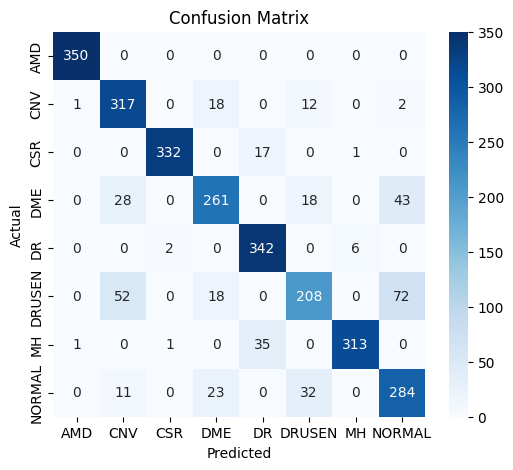

In [27]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [28]:
n_classes = len(class_names)

# Convert labels to one-hot
y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

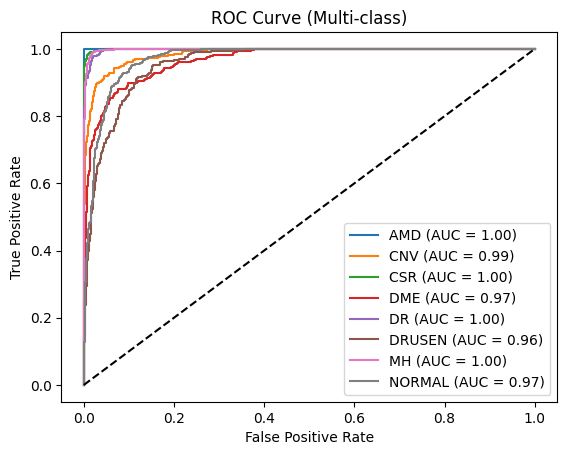

In [29]:
plt.figure()

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')  # diagonal line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-class)")
plt.legend()
plt.show()

In [30]:
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()

print("✅ Model Loaded Successfully")

✅ Model Loaded Successfully


In [31]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

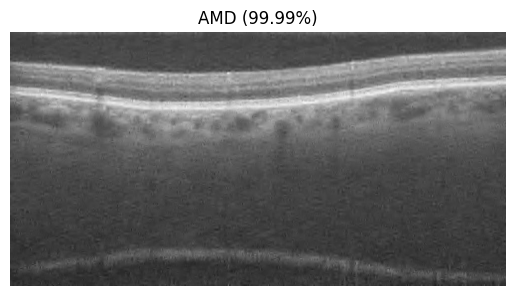

Prediction: AMD
Confidence: 99.99%


In [33]:
def show_prediction(image_path):
    
    # Load image
    image = Image.open(image_path).convert("RGB")
    
    # Preprocess
    input_img = transform(image).unsqueeze(0).to(device)

    # Prediction
    with torch.no_grad():
        outputs = model(input_img)
        probs = torch.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probs, 1)

    pred_class = class_names[predicted.item()]
    conf = confidence.item() * 100

    # Display
    plt.imshow(image)
    plt.title(f"{pred_class} ({conf:.2f}%)")
    plt.axis('off')
    plt.show()

    print("Prediction:", pred_class)
    print("Confidence:", f"{conf:.2f}%")

# 🔹 Test
show_prediction("/kaggle/input/datasets/obulisainaren/retinal-oct-c8/RetinalOCT_Dataset/RetinalOCT_Dataset/test/AMD/amd_test_1001.jpg") 